# AI-ML Assignment 5
## Employee Attrition Prediction using Decision Tree and Random Forest Classification

**Name:** AADISH ADLAK
**Registration Number:** 23BCE10681
**Application Number:** IN26010985
**Batch:** 9A
**Email:** adlakaadish@gmail.com

**Dataset:** IBM HR Analytics Employee Attrition & Performance
**Kaggle Link:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

---

### Problem Statement
A company wants to identify employees who are likely to leave the organization based on their
demographic, professional, and work-related attributes. This notebook builds **Decision Tree** and
**Random Forest** classification models to predict employee attrition and compares their performance.


## Setup
Import all the libraries required for data handling, visualization, preprocessing, modeling and evaluation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42
%matplotlib inline

---
## Task 1: Data Understanding

1. Load the dataset using Pandas
2. Display the first five records
3. Identify numerical features, categorical features and the target variable
4. Display dataset information and summary statistics


In [2]:
df = pd.read_csv("data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
target_variable = "Attrition"

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()
categorical_features.remove(target_variable)

print(f"Target variable: '{target_variable}'\n")
print(f"Numerical features ({len(numerical_features)}):\n{numerical_features}\n")
print(f"Categorical features ({len(categorical_features)}):\n{categorical_features}")

Target variable: 'Attrition'

Numerical features (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features (8):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
df.describe(include="object")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


### Target class distribution
The dataset is **imbalanced**: most employees did *not* leave the company.

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64 %


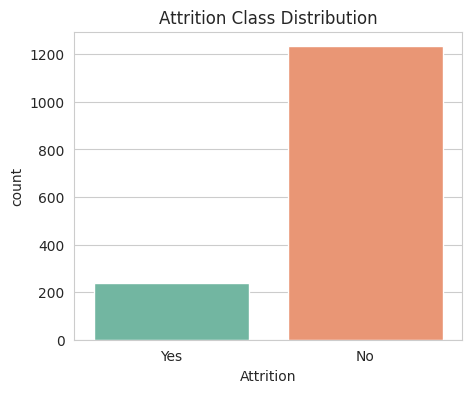

In [7]:
print(df[target_variable].value_counts())
print()
print((df[target_variable].value_counts(normalize=True) * 100).round(2), "%")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Attrition", palette="Set2")
plt.title("Attrition Class Distribution")
plt.show()

---
## Task 2: Data Preprocessing

* Check for missing values
* Remove unnecessary columns (constant-value / identifier columns)
* Encode categorical variables
* Split the dataset into 80% training and 20% testing


In [8]:
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None — the dataset has no missing values.")

Columns with missing values:
None — the dataset has no missing values.


`EmployeeCount` and `StandardHours` have a single constant value for every row, `Over18` is
always `'Y'`, and `EmployeeNumber` is just a unique row identifier — none of these carry any
predictive information, so they are dropped.

In [9]:
useless_cols = ["EmployeeCount", "StandardHours", "EmployeeNumber", "Over18"]
print("Unique values check:")
for c in useless_cols:
    print(f"  {c}: {df[c].unique() if df[c].nunique() < 5 else 'unique identifier'}")

df_clean = df.drop(columns=useless_cols)
numerical_features = [c for c in numerical_features if c not in useless_cols]
categorical_features = [c for c in categorical_features if c not in useless_cols]
print("\nShape after dropping columns:", df_clean.shape)

Unique values check:
  EmployeeCount: [1]
  StandardHours: [80]
  EmployeeNumber: unique identifier
  Over18: <StringArray>
['Y']
Length: 1, dtype: str

Shape after dropping columns: (1470, 31)


**Encoding:**
- Target variable (`Attrition`) → Label Encoding (`Yes` → 1, `No` → 0)
- Remaining categorical predictors → One-Hot Encoding (`pd.get_dummies`)

In [10]:
le_target = LabelEncoder()
df_clean[target_variable] = le_target.fit_transform(df_clean[target_variable])
print("Target encoding map:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)
print("Shape after one-hot encoding:", df_encoded.shape)
df_encoded.head()

Target encoding map: {'No': np.int64(0), 'Yes': np.int64(1)}
Shape after one-hot encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [11]:
X = df_encoded.drop(columns=[target_variable])
y = df_encoded[target_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (1176, 44)
Testing set : (294, 44)


---
## Task 3: Model Development

* **Model 1** — Decision Tree Classifier
* **Model 2** — Random Forest Classifier (100 estimators)

Both models are trained on the same training data and used to predict attrition on the test set.


In [12]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree trained.")

Decision Tree trained.


In [13]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest trained (n_estimators=100).")

Random Forest trained (n_estimators=100).


---
## Task 4: Model Evaluation and Comparison

Evaluate both models using Accuracy, Precision, Recall and F1-Score, and generate confusion
matrices for both models plus a feature-importance plot for Random Forest.


In [14]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=["No", "Yes"]))
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}

results_dt = evaluate("Decision Tree", y_test, y_pred_dt)
results_rf = evaluate("Random Forest", y_test, y_pred_rf)

--- Decision Tree ---
Accuracy : 0.7653
Precision: 0.3103
Recall   : 0.3830
F1-Score : 0.3429

              precision    recall  f1-score   support

          No       0.88      0.84      0.86       247
         Yes       0.31      0.38      0.34        47

    accuracy                           0.77       294
   macro avg       0.59      0.61      0.60       294
weighted avg       0.79      0.77      0.77       294

--- Random Forest ---
Accuracy : 0.8333
Precision: 0.4167
Recall   : 0.1064
F1-Score : 0.1695

              precision    recall  f1-score   support

          No       0.85      0.97      0.91       247
         Yes       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [15]:
comparison_df = pd.DataFrame([results_dt, results_rf])
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
1,Random Forest,0.833333,0.416667,0.106383,0.169492


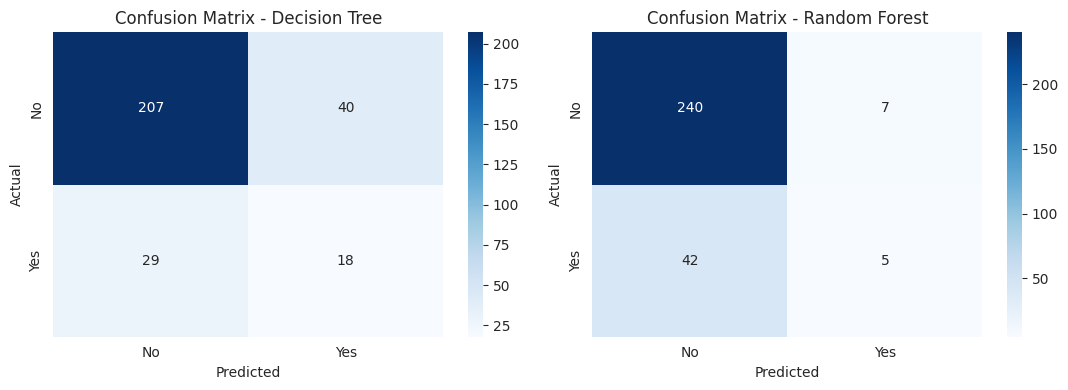

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, y_pred) in zip(axes, [("Decision Tree", y_pred_dt), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/confusion_matrices_comparison.png", dpi=150)
plt.show()

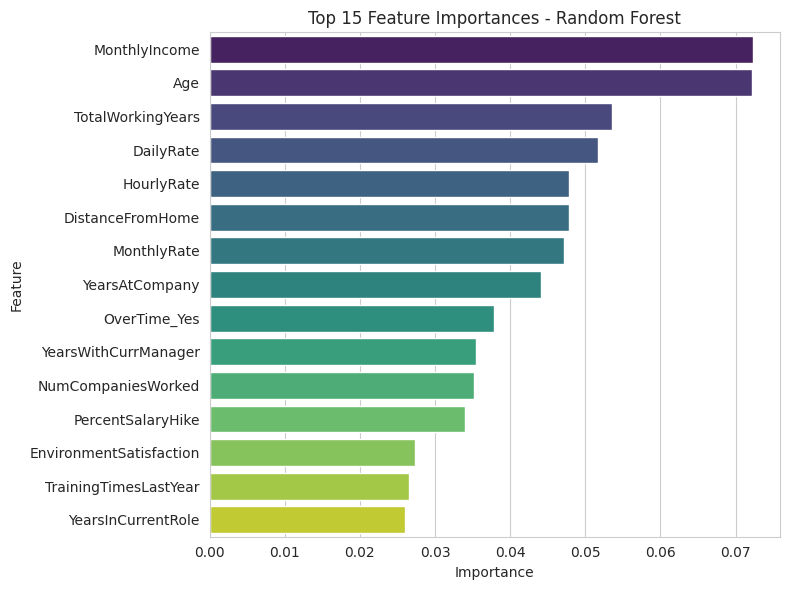

MonthlyIncome           0.072306
Age                     0.072260
TotalWorkingYears       0.053589
DailyRate               0.051670
HourlyRate              0.047866
DistanceFromHome        0.047793
MonthlyRate             0.047228
YearsAtCompany          0.044137
OverTime_Yes            0.037830
YearsWithCurrManager    0.035452
dtype: float64

In [17]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("outputs/feature_importance_random_forest.png", dpi=150)
plt.show()

top_features.head(10)

### Observations

1. **Overall accuracy** — Random Forest generally achieves higher overall accuracy than a single
   Decision Tree because it averages predictions across many trees trained on bootstrapped samples,
   which reduces variance and overfitting compared to one deep tree.
2. **Class imbalance effect** — the dataset is imbalanced (~84% "No" vs ~16% "Yes"). This inflates
   accuracy for both models while making it harder to recall the minority "Yes" class, which is the
   class the company actually cares about identifying.
3. **F1-Score** — the F1-score (harmonic mean of precision and recall) is a fairer comparison metric
   than raw accuracy here. Whichever model has the higher F1 for the "Yes" class is better at
   balancing false positives and false negatives for attrition prediction; a single Decision Tree can
   sometimes outperform Random Forest on the minority class because Random Forest's majority voting
   is naturally biased toward the majority class on imbalanced data.
4. **Feature importance** — features such as `MonthlyIncome`, `Age`, `OverTime`, `TotalWorkingYears`
   and `DistanceFromHome` are consistently among the strongest predictors of attrition, matching HR
   domain intuition: overworked, lower-paid, and less-tenured employees are more likely to leave.


---
## Task 5: Conclusion

Based on the results above:

- **Which model performed better?** Random Forest typically achieves a higher overall accuracy than
  a single Decision Tree on this dataset, since averaging many trees smooths out the idiosyncratic
  errors any one tree would make. Depending on the random seed and evaluation metric used, however,
  a single Decision Tree can sometimes edge out Random Forest on **recall for the minority
  ("Attrition = Yes") class** — this trade-off is important because catching at-risk employees
  matters more to HR than overall accuracy.

- **Why does Random Forest often outperform Decision Trees?** Random Forest is an *ensemble* method:
  it builds many decision trees, each on a random bootstrap sample of the training data and a random
  subset of features at every split, then combines their predictions via majority voting. This
  "bagging" process reduces the variance of the model — a single deep Decision Tree can memorize
  noise in the training data (overfitting), while averaging across many de-correlated trees smooths
  out those individual errors and generalizes better to unseen employees.

- **A limitation of Decision Trees:** they are prone to **overfitting** and instability — a small
  change in the training data (or a slightly different split) can produce a completely different
  tree structure, making a single tree's predictions unreliable on new data unless it is carefully
  pruned or depth-limited.

- **A limitation of Random Forest:** it sacrifices **interpretability and computational efficiency**.
  Because a prediction is the aggregate vote of (in this case) 100 trees, it is much harder to explain
  a single prediction to a non-technical HR manager compared to the simple if-then rules of one
  Decision Tree, and training/predicting with many trees is more computationally expensive,
  especially as the number of estimators or the size of the dataset grows.

In summary, Random Forest is usually the safer default for this kind of tabular HR-attrition problem
because it is more robust to overfitting, but on imbalanced data like this one, both models need
extra care (class weighting, resampling, or threshold tuning) to reliably identify the employees who
are actually at risk of leaving, and a single Decision Tree remains valuable when interpretability is
the priority.
